In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (13910, 131)


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V121,V122,V123,V124,V125,V126,V127,V128,V129,Class
0,1,12285.6582,4.076635,4.842317,7.509393,10.822436,-1.312657,-1.853717,-6.924985,11800.9233,...,1784.5324,1.907000,1.729200,4.881194,8.623828,-0.314110,-0.661556,-3.521663,10.0,4
1,2,-35.6889,0.993944,0.166099,0.489363,3.484663,-0.130298,-0.528364,-3.735347,266.4145,...,904.9898,1.433707,1.068069,2.532958,5.369720,-0.183779,-0.534087,-4.635975,50.0,3
2,3,63927.2217,14.956941,19.971376,29.188512,33.291320,-10.433776,-16.062245,-49.490143,57405.8483,...,14585.7879,8.189021,6.099452,12.127991,15.709651,-3.887082,-6.731473,-19.326895,250.0,4
3,4,2992.9019,1.380553,0.808910,1.288259,4.660135,-0.755903,-1.120470,-4.075213,4301.4033,...,6044.5554,3.488295,2.662288,5.938297,8.544508,-1.567322,-2.701235,-6.472439,600.0,3
4,5,57524.7812,11.912566,14.631496,19.809240,23.715868,-9.084750,-11.770585,-39.234003,50051.0703,...,10580.1006,5.752675,3.880740,8.545897,11.831716,-2.655521,-4.312744,-8.510591,150.0,4


In [3]:
y = df["Class"].values        # labela (samo za evaluaciju)
X_raw = df.drop(columns=["Class"])

print("X shape:", X_raw.shape)
print("y shape:", y.shape)
print("Broj klasa:", np.unique(y).size)


X shape: (13910, 130)
y shape: (13910,)
Broj klasa: 6


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_scaled)


In [8]:
# from sklearn.cluster import HDBSCAN
import hdbscan

hdb = hdbscan.HDBSCAN(
    min_cluster_size=50,   # možeš kasnije da tunuješ
    min_samples=None
)

clusters = hdb.fit_predict(X_scaled)

np.unique(clusters, return_counts=True)


(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
        33, 34, 35, 36, 37, 38, 39, 40]),
 array([8380,  265,   55,  122,   98,   80,  114,  101,   96,   55,  282,
          51,  274,  104,  118,  203,   70,   77,   51,   56,  134,  125,
         414,   96,  190,   50,  300,   54,   94,  364,  143,  131,   74,
         114,  278,   98,   55,  107,   64,  107,  106,  160]))

In [9]:
pd.DataFrame(clusters, columns=["cluster"]).to_csv("../results/hdbscan_clusters_full.csv", index=False)

In [10]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

mask = clusters != -1  # izbacujemo noise

sil = np.nan
db = np.nan
ari = np.nan
nmi = np.nan

if mask.sum() > 0 and len(np.unique(clusters[mask])) > 1:
    sil = silhouette_score(X_scaled[mask], clusters[mask])
    db = davies_bouldin_score(X_scaled[mask], clusters[mask])
    ari = adjusted_rand_score(y[mask], clusters[mask])
    nmi = normalized_mutual_info_score(y[mask], clusters[mask])

sil, db, ari, nmi


(np.float64(0.5149930647442327),
 np.float64(0.7319822602519055),
 0.26652313610358236,
 np.float64(0.6299752518513523))

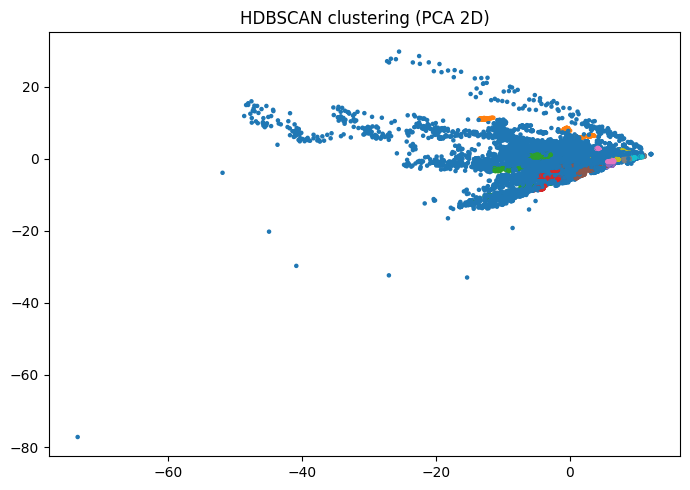

In [11]:
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=clusters,
    s=5,
    cmap="tab10"
)
plt.title("HDBSCAN clustering (PCA 2D)")
plt.tight_layout()
plt.show()


In [12]:
results = pd.DataFrame([{
    "Algorithm": "HDBSCAN",
    "K_found": len(set(clusters)) - (1 if -1 in clusters else 0),
    "Noise_points": int(np.sum(clusters == -1)),
    "Silhouette": sil,
    "Davies_Bouldin": db,
    "ARI": ari,
    "NMI": nmi
}])

results.to_csv("../results/hdbscan_results.csv", index=False)
results


,Algorithm,K_found,Noise_points,Silhouette,Davies_Bouldin,ARI,NMI
0,HDBSCAN,41,8380,0.514993,0.731982,0.266523,0.629975
